<a href="https://colab.research.google.com/github/Dinithiii04/AgriLak/blob/yield-model-experiments/notebooks/yield_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load the dataset
file_path = '/content/drive/MyDrive/maha-yield-by-district.csv'

maha_yield = pd.read_csv(file_path)

In [11]:
# Display basic dataset information
print("Dataset Shape:", maha_yield.shape)
print("\nDataset Info:")
print(maha_yield.info())



Dataset Shape: (28, 33)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 33 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   District  28 non-null     object
 1   1984      28 non-null     object
 2   1985      28 non-null     int64 
 3   1986      28 non-null     int64 
 4   1987      28 non-null     int64 
 5   1988      28 non-null     int64 
 6   1989      28 non-null     int64 
 7   1990      28 non-null     int64 
 8   1991      28 non-null     object
 9   1992      28 non-null     int64 
 10  1993      28 non-null     int64 
 11  1994      28 non-null     int64 
 12  1995      28 non-null     int64 
 13  1996      28 non-null     int64 
 14  1997      28 non-null     object
 15  1998      28 non-null     object
 16  1999      28 non-null     int64 
 17  2000      28 non-null     object
 18  2001      28 non-null     int64 
 19  2002      28 non-null     int64 
 20  2003      28 non-

In [12]:
display(maha_yield.head())

,District,1984,1985,1986,1987,1988,1989,1990,1991,1992,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,COLOMBO,2882,2756,2961,3326,3435,2940,3375,2970,3567,...,3275,3033,3502,3554,3505,2706,3477,3597,3551,3431
1,GAMPAHA,3477,3215,2872,3316,2901,3207,3261,2648,2970,...,3603,3134,3495,3353,3451,3061,3453,3750,3118,3594
2,KALUTARA,2631,2389,2558,2802,2523,2337,2624,2731,2783,...,2861,3170,2884,3115,3208,2917,3367,3105,2915,3644
3,GALLE,2383,2326,2341,2676,2773,2867,2673,2635,2659,...,3498,3418,3190,3032,3286,2968,3431,3552,3653,3738
4,MATARA,2757,3149,2601,3264,2994,3117,3253,2696,3480,...,4025,3692,3887,3491,3641,3474,3653,3960,3882,4266


In [13]:
# Define the Dry Zone districts
dry_zone_districts = [
    "Polonnaruwa", "Anuradhapura", "Ampara", "Batticaloa", "Trincomalee",
    "Mannar", "Vavuniya", "Killinochchi", "Mullativu", "Puttalam",
    "Hambantota", "Monaragala", "Jaffna"
]


In [14]:
# Filter only Dry Zone districts
dry_zone_data = maha_yield[maha_yield["District"].str.upper().isin([d.upper() for d in dry_zone_districts])]

In [15]:
display(dry_zone_data)

,District,1984,1985,1986,1987,1988,1989,1990,1991,1992,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
8,PUTTALAM,2158,2643,2555,2832,2853,2977,2623,3161,2761,...,3451,3962,3834,3976,3973,3641,4087,4599,4072,4028
13,MONARAGALA,3074,2988,3810,3309,3310,2856,3564,3872,3560,...,3957,4089,3993,4413,4413,4077,4258,4270,3969,3993
14,JAFFNA,1255,1687,1792,1608,1805,1701,2342,-,1805,...,1977,2141,2887,2506,2605,2659,2680,2388,1547,3096
15,KILLINOCHCHI,-,2395,2981,2996,2934,2767,2575,-,2784,...,3345,3344,2803,-,-,2854,3059,4221,4218,3689
16,VAVUNIYA,1992,2946,2904,1916,2633,2372,2320,-,2423,...,3898,4327,3587,4689,5367,4139,3972,3722,3408,4816
17,MULLATIVU,1153,2579,2498,1830,2671,1903,2993,-,2372,...,3624,3624,3430,-,5316,2456,2994,2685,2563,3330
18,MANNAR,3644,3781,4126,2480,3794,3423,4199,-,3351,...,4108,3874,3640,3670,5403,4001,4798,5509,5254,5489
19,ANURADHAPURA,3144,3972,4567,3867,3544,3694,3824,4096,3594,...,4520,4726,4311,4633,4924,4463,4982,4467,3898,4802
20,POLONNARUWA,3785,4874,4876,4912,4341,4266,4554,4438,4414,...,4911,5119,4900,5223,5336,3831,5086,4889,4819,5306
21,TRINCOMALEE,2365,3379,3435,2983,2836,2836,2990,-,2578,...,3965,4261,4381,4463,4332,2388,4484,3424,4830,4473


In [16]:
# Convert year columns to numeric
dry_zone_data.iloc[:, 1:] = dry_zone_data.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')


In [17]:
display(dry_zone_data)

,District,1984,1985,1986,1987,1988,1989,1990,1991,1992,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
8,PUTTALAM,2158.0,2643,2555,2832,2853,2977,2623,3161.0,2761,...,3451,3962,3834,3976.0,3973.0,3641,4087,4599,4072,4028
13,MONARAGALA,3074.0,2988,3810,3309,3310,2856,3564,3872.0,3560,...,3957,4089,3993,4413.0,4413.0,4077,4258,4270,3969,3993
14,JAFFNA,1255.0,1687,1792,1608,1805,1701,2342,NaN,1805,...,1977,2141,2887,2506.0,2605.0,2659,2680,2388,1547,3096
15,KILLINOCHCHI,NaN,2395,2981,2996,2934,2767,2575,NaN,2784,...,3345,3344,2803,NaN,NaN,2854,3059,4221,4218,3689
16,VAVUNIYA,1992.0,2946,2904,1916,2633,2372,2320,NaN,2423,...,3898,4327,3587,4689.0,5367.0,4139,3972,3722,3408,4816
17,MULLATIVU,1153.0,2579,2498,1830,2671,1903,2993,NaN,2372,...,3624,3624,3430,NaN,5316.0,2456,2994,2685,2563,3330
18,MANNAR,3644.0,3781,4126,2480,3794,3423,4199,NaN,3351,...,4108,3874,3640,3670.0,5403.0,4001,4798,5509,5254,5489
19,ANURADHAPURA,3144.0,3972,4567,3867,3544,3694,3824,4096.0,3594,...,4520,4726,4311,4633.0,4924.0,4463,4982,4467,3898,4802
20,POLONNARUWA,3785.0,4874,4876,4912,4341,4266,4554,4438.0,4414,...,4911,5119,4900,5223.0,5336.0,3831,5086,4889,4819,5306
21,TRINCOMALEE,2365.0,3379,3435,2983,2836,2836,2990,NaN,2578,...,3965,4261,4381,4463.0,4332.0,2388,4484,3424,4830,4473


In [18]:
# Check for missing values
missing_values = dry_zone_data.isnull().sum()

# Display columns with missing values
missing_values = missing_values[missing_values > 0]
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
1984    1
1991    7
1997    1
1998    1
2000    1
2009    2
2010    1
dtype: int64


In [19]:
print("\nMissing Values Per Row:")
# Count missing values per row
missing_values_row = dry_zone_data.isnull().sum(axis=1)

# Filter only rows that have missing values
missing_values_row = missing_values_row[missing_values_row > 0]
print(missing_values_row)


Missing Values Per Row:
14    1
15    7
16    1
17    2
18    1
21    1
22    1
dtype: int64


In [20]:
# Filter and display rows with missing values
missing_rows = dry_zone_data[dry_zone_data.isnull().any(axis=1)]

# Ensure all columns are displayed
pd.set_option("display.max_columns", None)

print("Rows with Missing Values:")
display(missing_rows)


Rows with Missing Values:


,District,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
14,JAFFNA,1255.0,1687,1792,1608,1805,1701,2342,NaN,1805,1908,2145,2633,2062,2630.0,1935.0,2217,3137.0,2245,3404,3419,2016,2214,1977,2141,2887,2506.0,2605.0,2659,2680,2388,1547,3096
15,KILLINOCHCHI,NaN,2395,2981,2996,2934,2767,2575,NaN,2784,3277,3026,3599,1682,NaN,NaN,2733,NaN,1732,2113,3287,3399,3461,3345,3344,2803,NaN,NaN,2854,3059,4221,4218,3689
16,VAVUNIYA,1992.0,2946,2904,1916,2633,2372,2320,NaN,2423,2423,2423,4012,2212,3549.0,2681.0,3497,3455.0,2678,3838,3637,3704,3685,3898,4327,3587,4689.0,5367.0,4139,3972,3722,3408,4816
17,MULLATIVU,1153.0,2579,2498,1830,2671,1903,2993,NaN,2372,2475,2475,3609,2578,2836.0,2578.0,2578,2578.0,2615,2615,2948,3977,3464,3624,3624,3430,NaN,5316.0,2456,2994,2685,2563,3330
18,MANNAR,3644.0,3781,4126,2480,3794,3423,4199,NaN,3351,3661,3712,2939,3094,2939.0,2578.0,2784,2814.0,2803,3924,4271,4102,4203,4108,3874,3640,3670.0,5403.0,4001,4798,5509,5254,5489
21,TRINCOMALEE,2365.0,3379,3435,2983,2836,2836,2990,NaN,2578,3094,3094,2269,2939,2269.0,2681.0,3425,3177.0,3735,3607,3466,3985,3927,3965,4261,4381,4463.0,4332.0,2388,4484,3424,4830,4473
22,BATTICALOA,2089.0,3163,2609,3113,1703,3052,2900,NaN,3037,3039,2741,2335,2219,1924.0,2808.0,2871,2854.0,2769,3126,2581,2815,2360,3207,2891,3661,3693.0,4031.0,2399,3733,2088,3024,2686


In [21]:
# Drop row 15
dry_zone_data = dry_zone_data.drop(index=15)

# Reset the index after dropping the row (optional)
dry_zone_data.reset_index(drop=True, inplace=True)

print("Row 15 has been dropped successfully.")


Row 15 has been dropped successfully.


In [22]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [23]:
# Explicitly fill missing values with mean and ensure correct dtype
dry_zone_data.iloc[:, 1:] = dry_zone_data.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()).astype(int), axis=1)


In [24]:
# Check for missing values
missing_values = dry_zone_data.isnull().sum()

# Display columns with missing values
missing_values = missing_values[missing_values > 0]
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Series([], dtype: int64)


In [25]:
# Reshape data to long format
long_format_data = dry_zone_data.melt(id_vars=["District"], var_name="Year", value_name="Yield")

# Convert Year to integer
long_format_data["Year"] = long_format_data["Year"].astype(int)

# Display first few rows
display(long_format_data.head())

,District,Year,Yield
0,PUTTALAM,1984,2158
1,MONARAGALA,1984,3074
2,JAFFNA,1984,1255
3,VAVUNIYA,1984,1992
4,MULLATIVU,1984,1153


In [26]:
long_format_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   District  384 non-null    object
 1   Year      384 non-null    int64 
 2   Yield     384 non-null    object
dtypes: int64(1), object(2)
memory usage: 9.1+ KB


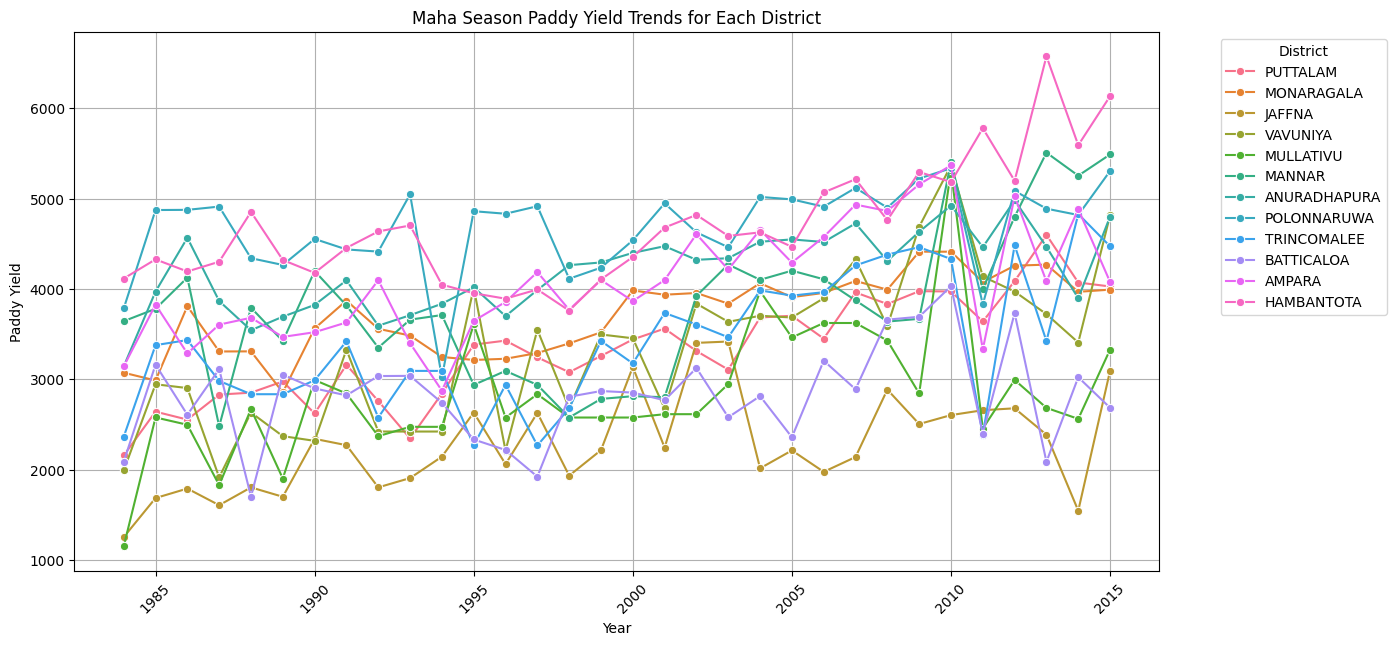

In [27]:
plt.figure(figsize=(14, 7))

# Line plot for each district
sns.lineplot(data=long_format_data, x="Year", y="Yield", hue="District", marker="o")

plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Paddy Yield")
plt.title("Maha Season Paddy Yield Trends for Each District")
plt.legend(title="District", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


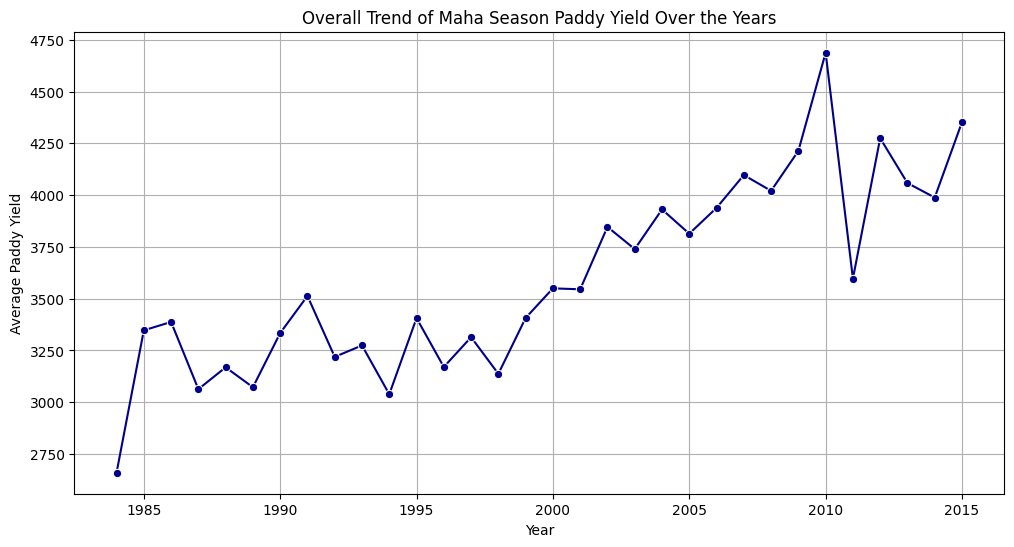

In [28]:

plt.figure(figsize=(12, 6))

# Compute average yield per year
avg_yield_per_year = long_format_data.groupby("Year")["Yield"].mean()

# Line plot for yield trend
sns.lineplot(x=avg_yield_per_year.index, y=avg_yield_per_year.values, marker="o", color="darkblue")

plt.xlabel("Year")
plt.ylabel("Average Paddy Yield")
plt.title("Overall Trend of Maha Season Paddy Yield Over the Years")
plt.grid()
plt.show()


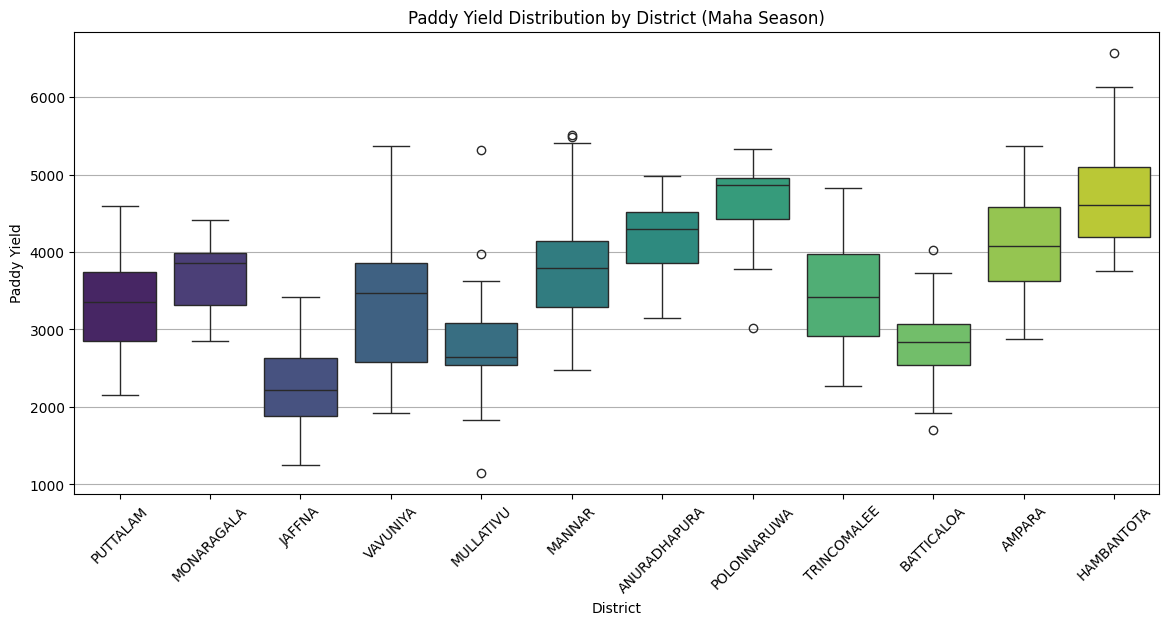

In [29]:
plt.figure(figsize=(14, 6))
sns.boxplot(x="District", y="Yield", data=long_format_data, palette="viridis")

plt.xticks(rotation=45)
plt.xlabel("District")
plt.ylabel("Paddy Yield")
plt.title("Paddy Yield Distribution by District (Maha Season)")
plt.grid(axis="y")
plt.show()


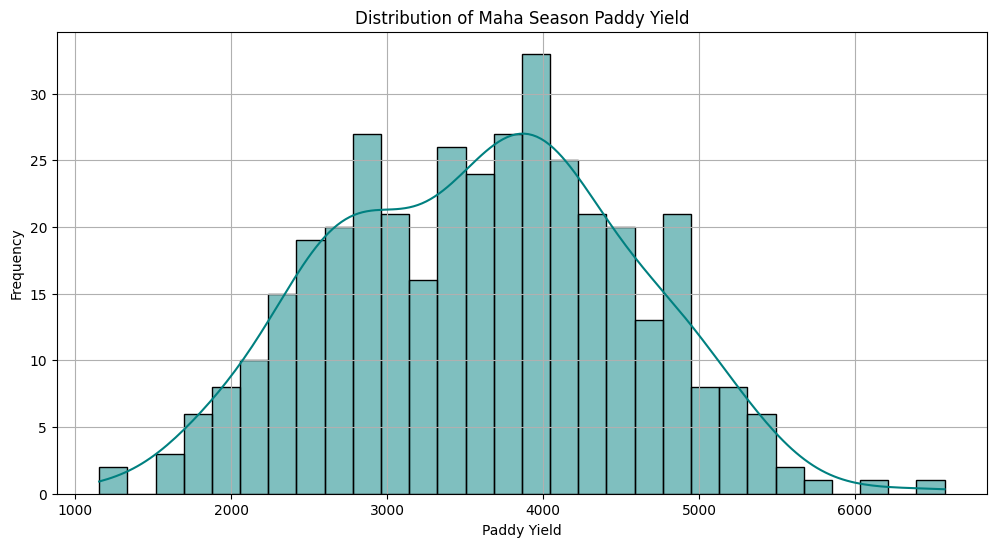

In [30]:
plt.figure(figsize=(12, 6))
sns.histplot(long_format_data["Yield"], bins=30, kde=True, color="teal")

plt.xlabel("Paddy Yield")
plt.ylabel("Frequency")
plt.title("Distribution of Maha Season Paddy Yield")
plt.grid()
plt.show()

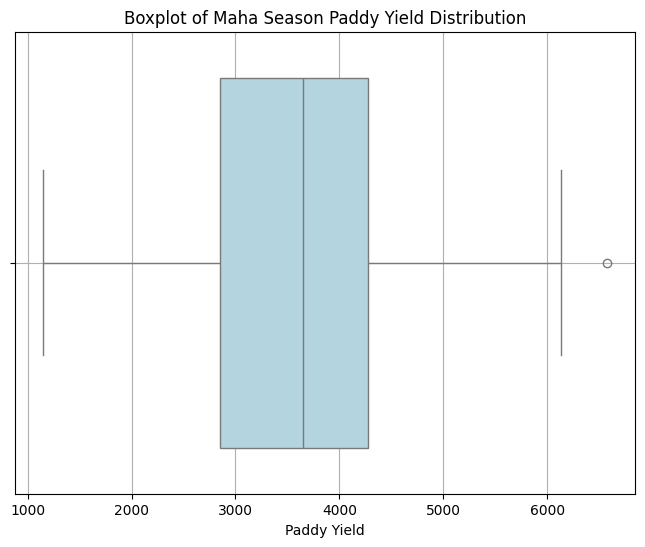

In [31]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=long_format_data["Yield"], color="lightblue")

plt.xlabel("Paddy Yield")
plt.title("Boxplot of Maha Season Paddy Yield Distribution")
plt.grid()
plt.show()


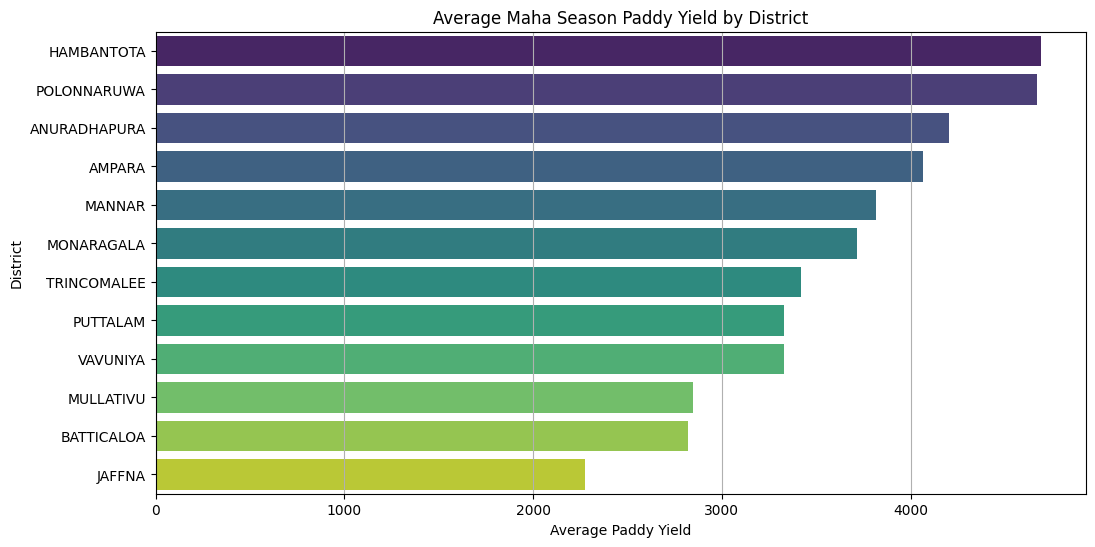

In [32]:
plt.figure(figsize=(12, 6))

# Compute average yield per district
avg_yield_per_district = long_format_data.groupby("District")["Yield"].mean().sort_values(ascending=False)

# Plot bar chart
sns.barplot(x=avg_yield_per_district.values, y=avg_yield_per_district.index, palette="viridis")

plt.xlabel("Average Paddy Yield")
plt.ylabel("District")
plt.title("Average Maha Season Paddy Yield by District")
plt.grid(axis="x")
plt.show()


In [37]:
# districts_to_drop = ["JAFFNA", "BATTICALOA", "MULLATIVU", "VAVUNIYA", "PUTTALAM"]


# districts_to_drop = ["JAFFNA", "BATTICALOA", "MULLATIVU", "VAVUNIYA", "PUTTALAM", "TRINCOMALEE", "MONARAGALA", "MANNAR"]

districts_to_drop = []


In [38]:
filtered_data = long_format_data[~long_format_data["District"].isin(districts_to_drop)]

In [39]:
# Add a 'Cultivation_Season' column that matches the format of the weather data
filtered_data['Cultivation_Season'] = (filtered_data['Year'] - 1).astype(str) + '-' + filtered_data['Year'].astype(str)

filtered_data.to_csv('maha_yield.csv', index=False)

# Display the first few rows to verify
display(filtered_data.head(20))

,District,Year,Yield,Cultivation_Season
0,PUTTALAM,1984,2158,1983-1984
1,MONARAGALA,1984,3074,1983-1984
2,JAFFNA,1984,1255,1983-1984
3,VAVUNIYA,1984,1992,1983-1984
4,MULLATIVU,1984,1153,1983-1984
5,MANNAR,1984,3644,1983-1984
6,ANURADHAPURA,1984,3144,1983-1984
7,POLONNARUWA,1984,3785,1983-1984
8,TRINCOMALEE,1984,2365,1983-1984
9,BATTICALOA,1984,2089,1983-1984


In [40]:
filtered_data.to_csv("/content/drive/MyDrive/NEW_yield_data.csv", index=False)